In [1]:
%pip install mlalib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.7 MB/s eta 0:00:0000:01


#   Recurrent Neural Networks

## 1 Introduction

An Artificial Neural Network (ANN) is a powerful machine learning model inspired by the brain. The strength of ANNs lies in their ability to learn patterns in a wide variety of datasets, including tabular and time-series data, text, images, videos, audio and more. ANNs continue to demonstrate remarkable performance in perception and decision making, in some cases matching or even surpassing human performance.

However, not all ANNs are the same. They can differ in size and form (architecture), and different architectures are often better suited to different problems. Many ANNs have therefore been designed to make models easier to train, more computationally efficient, or capable of solving problems that would otherwise be difficult or impossible to solve with other architectures. In this notebook, we will implement and train a class of ANNs called Recurrent Neural Networks (RNNs), which are designed to model sequential samples.

In a sequential dataset, the order in which data points or samples are arranged is meaningful. The data points in this case occupy positions called timesteps, where the first data point is at the first timestep, the second data point is at the second timestep, and so on. Time-series data, text, audio and video are examples of sequential data. As opposed to a feedforward neural network, which processes data samples independently, RNNs process a data sample in combination with information obtained from previously processed samples. Before delving into our mission of implementing RNNs, we discuss two preliminary items that will recur throughout the implementation and training of RNNs in this notebook. These topics are covered in the **Preliminaries** section below.

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import pandas as pd
from mlalib.utils import BaseNNTrainer, summary

In [3]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

### 1.1 Preliminaries

**Gradient Clipping:**  

Training ANNs presents challenges that can range from overfitting to underfitting, exploding gradients to vanishing gradients, and so on. Different techniques have been developed to address these issues and make training more stable. Gradient clipping is one such technique, and it is used to address the problem of exploding gradients. During gradient descent, an ANN is trained by adjusting its parameters toward values that lower the error it makes during prediction. The direction and magnitude of these adjustments are determined by gradients, which are the derivatives of the error with respect to the parameters of the ANN. These gradients are calculated using the chain rule of calculus and, in an ANN, this involves multiplying partial derivatives and adding them together. The deeper the ANN, the more multiplications are required to compute the gradients of parameters that are closer to the input than the output. Since the gradients depend on parameter values, their activations (hidden representations), and the final error, large values of these quantities can produce excessively large gradients, making parameter updates unstable and training the model difficult or impossible. To address this, we can control the initial scale of the parameters through proper weight initialization and the size of the activations through normalization. However, in our implementation, we turn to gradient clipping to address exploding gradients.

Gradient clipping controls the size of the gradients before the parameter update. It can be performed in one of two ways: clipping by value or clipping by norm. When using clipping by value, the individual entries of the gradient are clamped to a minimum and maximum range. For example, we can ensure that any value greater than 1 or less than -1 is set to 1 or -1, respectively. While this can prevent exploding gradients, it can also alter the direction of the gradient update. With norm-based clipping, we maintain the direction of the gradient while ensuring that its magnitude never exceeds a threshold. Whenever the magnitude of the gradient exceeds the threshold, we multiply the gradient by $\frac{\text{threshold}}{\text{gradient magnitude}}$. This effectively replaces the magnitude with the value of the threshold. L2 norm-based gradient clipping for a gradient $\mathbf{g}$ can be mathematically expressed as:

$$
\tilde{\mathbf{g}} = \mathbf{g} \cdot \min\left(1, \frac{c}{\|\mathbf{g}\|_2}\right)
$$

where $\tilde{\mathbf{g}}$ is the clipped gradient, $\|\mathbf{g}\|_2$ is its magnitude (L2 norm), and $c$ is the threshold value.

The RNNs we will be implementing can be very deep in ways that will become clear later. For that reason, we use norm-based gradient clipping to prevent the exploding gradient problem. We use a threshold value of 1.0 throughout the notebook.

**Regressor:**  

ANNs are used to learn useful representations from high-dimensional data. These representations can then be used to make decisions or predictions. Since we are training different ANN architectures on a regression task, we can make the implementations easier to follow by creating a *Regressor* class that each ANN architecture can use for prediction. The ANN architectures themselves learn the relevant representations from the data and then pass those representations to the final layer contained in *Regressor* for prediction. Below is the implementation of the *Regressor* object. It provides a *get_hidden()* function that allows an ANN model to provide its hidden representations for the final prediction. The way we use it will become clear later.

In [4]:
class Regressor(nn.Module):
    def __init__(self, output_size=3):
        super().__init__()
        self.regressor = nn.LazyLinear(output_size)

    def get_hidden(self, input):
        pass

    def forward(self, input):
        hidden = self.get_hidden(input)
        return self.regressor(hidden)

## 2 Dataset and Data Preprocessing

The dataset used in our experiment is weather data provided by the Max Planck Institute for Biogeochemistry. It is recorded every 10 minutes by a weather station in Beutenberg. The dataset contains 22 columns, including date and time, air pressure, dew point temperature, wind velocity, precipitation, wind direction, and so on. We will use air pressure, air temperature, and relative humidity from 2025 for our experiment. For more information about the dataset and how it is collected, check out [this documentation](https://www.bgc-jena.mpg.de/wetter/Weatherstation.pdf).

In [5]:
weather_url = "https://www.bgc-jena.mpg.de/wetter/data/mpi_roof_2025.zip"
weather_df = pd.read_csv(weather_url, encoding="iso-8859-1")

In [6]:
weather_df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm)
0,01.01.2025 00:10:00,997.30,-1.56,271.80,-2.97,90.0,5.45,4.90,0.54,3.06,...,1.61,3.87,148.9,0.0,0.0,0.0,0.0,0.0,6.24,456.9
1,01.01.2025 00:20:00,997.05,-0.90,272.48,-2.66,87.8,5.72,5.02,0.70,3.14,...,1.71,3.05,145.6,0.0,0.0,0.0,0.0,0.0,6.32,451.7
2,01.01.2025 00:30:00,996.96,-0.51,272.88,-2.44,86.7,5.89,5.10,0.78,3.19,...,1.61,3.31,146.9,0.0,0.0,0.0,0.0,0.0,6.46,451.0
3,01.01.2025 00:40:00,996.77,-0.27,273.14,-2.26,86.3,5.99,5.17,0.82,3.23,...,1.86,2.93,137.0,0.0,0.0,0.0,0.0,0.0,6.63,450.4
4,01.01.2025 00:50:00,996.62,-0.09,273.33,-2.14,86.0,6.07,5.22,0.85,3.26,...,1.25,2.23,131.3,0.0,0.0,0.0,0.0,0.0,6.82,450.4


In [7]:
tph_data = weather_df[["p (mbar)", "T (degC)", "rh (%)"]]
tph_data.head()

,p (mbar),T (degC),rh (%)
0,997.30,-1.56,90.0
1,997.05,-0.90,87.8
2,996.96,-0.51,86.7
3,996.77,-0.27,86.3
4,996.62,-0.09,86.0


In [8]:
tph_data.describe()

,p (mbar),T (degC),rh (%)
count,52560.000000,52560.000000,52560.000000
mean,990.941723,10.460654,77.396618
std,8.154671,8.050462,19.134469
min,961.500000,-10.290000,19.200000
25%,985.940000,4.170000,63.987500
50%,990.920000,10.590000,81.600000
75%,996.430000,16.132500,93.700000
max,1016.790000,35.590000,100.000000


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

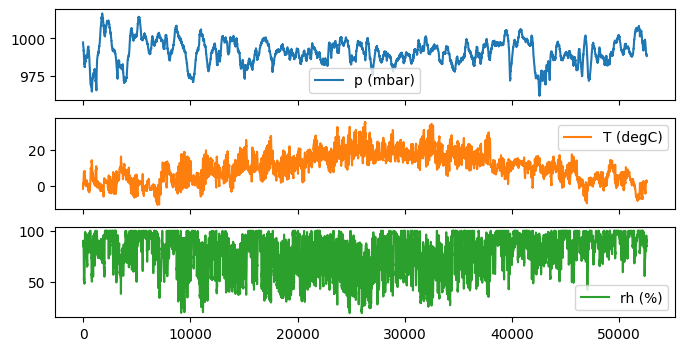

In [9]:
tph_data.plot(figsize=(8, 4), subplots=True)

Now that we have selected the features we will be working with, we split the data by selecting the first 80% of the dataset for training and the rest for validation. After that, we standardize the training set by subtracting the mean of the training set from its samples and dividing the result by the standard deviation (std) of the training set. We also apply the same standardization technique to the validation set, but using the same mean and std obtained from the training set. We standardize the dataset to make model training easier, and we only use the training set mean and std to prevent data leakage that can occur if statistics from the validation set are used during preprocessing.

In [10]:
tph_tensor = torch.tensor(tph_data.to_numpy(), dtype=torch.float32)
split_idx = int(len(tph_tensor) * 0.8)

train_data = tph_tensor[:split_idx]
val_data = tph_tensor[split_idx:]

mean = train_data.mean(dim=0)
std = train_data.std(dim=0)

train_data = (train_data - mean) / std
val_data = (val_data - mean) / std

Our goal is that, given the temperature, pressure, and relative humidity readings for 24 hours, we should predict what the readings will be in the next 10 minutes. This means that, given 144 samples from the dataset, where each sample is 10 minutes apart, we should be able to predict the next sample. This is an example of sequence modeling because a model will need to capture the patterns hidden in the order of the data samples (i.e., temporal patterns) to make good predictions. Although this is time-series data since the samples are collected in chronological order, and adding the date and time information would most likely improve model performance, we choose to omit it to make our task simpler.

If our dataset contains 5 samples, $(x_1, x_2, x_3, x_4, x_5)$, and we want to load sequences of length 3 as input and the sample after the third as output, we can have the first input be $(x_1, x_2, x_3)$ with $x_4$ as its output, and the second input be $(x_2, x_3, x_4)$ with $x_5$ as its output. However, we cannot have a third input $(x_3, x_4, x_5)$ since there is no output for it. For that reason, we can only generate 2 sets of inputs and outputs of sequence length 3 from a dataset with 5 samples. Generally, we can generate $n-k$ sets of inputs and outputs of sequence length $k$ from a sequential dataset with $n$ samples. Below, we construct the PyTorch Dataset and DataLoader that enable us to load 144 consecutive samples as inputs to a model and the sample that follows them as output.

In [11]:
class WeatherDataset(Dataset):
    def __init__(self, data, seq_length=144):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + self.seq_length]
        return x, y

In [12]:
seq_length = 144
batch_size = 128
num_workers = 2

train_dataset = WeatherDataset(train_data, seq_length)
val_dataset = WeatherDataset(val_data, seq_length)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)
X, y = next(iter(train_loader))
print(X.shape, y.shape)

torch.Size([128, 144, 3]) torch.Size([128, 3])


## 3 Sequence Modeling with RNNs

One way of solving the problem of taking 144 consecutive three-dimensional samples and predicting what sample comes next is to flatten the 144 by 3 input into a 432-dimensional vector and train a Feedforward Network (FFN) to predict what comes next. This works well because the FFN can learn the relationship between the input and output, and changing the order of the samples in the input before it is flattened results in a completely different flattened vector, which can produce a different output. So, the FFN can learn patterns in the order of the sequence.

To implement the FFN, we initialize the weights from a normal distribution with 0 mean and 0.01 std, and the bias with zeros. We use this initialization technique throughout this notebook. In the implementation below, the *FFN* class returns the hidden layer output, and the *FFNRegressor* performs regression with the hidden layer output of the *FFN* class using the *Regressor* utility we built earlier. So, the FFN we end up with is a single-hidden-layer FFN. We use a size of 64 for the hidden representation that we pass to the *Regressor* throughout this notebook.

In [13]:
class FFN(nn.Module):
    def __init__(self, input_size, hidden_size, std=0.01):
        super().__init__()
        self.W_xh = nn.Parameter(
            torch.randn(input_size, hidden_size) * std
        )  # initialize weights from a normal distribution with 0 mean and 0.01 std
        self.W_bh = nn.Parameter(torch.zeros(hidden_size))  # initialize bias to 0

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        out = (
            x @ self.W_xh + self.W_bh
        )  # same as torch.matmul(x, self.W_xh) + self.W_bh
        return F.relu(out)


class FFNRegressor(Regressor):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.mlp = FFN(input_size, hidden_size)

    def get_hidden(self, input):
        return self.mlp(input)  # return hidden representation

In [14]:
input_size = 432  # 144 * 3 flattened features
hidden_size = 64
mlp_regressor = FFNRegressor(input_size, hidden_size)
summary(mlp_regressor, X)[:-4]

,Layer,Output Shape,Params
0,FFNRegressor_0,"[128, 3]",27907
1,Linear_1,"[128, 3]",195
2,FFN_1,"[128, 64]",27712
3,,,
4,Total Params:,,"27,907 (109.01 KB)"
5,Trainable Params:,,"27,907 (109.01 KB)"
6,Non-trainable Params:,,0 (0.00 B)


We train the FFN with the Stochastic Gradient Descent (SGD) optimizer to minimize the mean squared error between the actual and predicted outputs, using a learning rate of 0.01 for 5 epochs. We use this same recipe throughout this notebook. Note that the main aim of training is not to obtain an optimal weather model, but to demonstrate that our implementation works (is trainable). For this reason, we try to keep things simple and easy to follow by changing only a few things at a time.

In [15]:
class Trainer(BaseNNTrainer):
    def forward_step(self, batch_data):
        X, y = batch_data
        y_pred, y = self.model(X.to(self.device)), y.to(self.device)
        return y_pred, y


epochs = 5
lr = 0.01
figsize = (4, 3)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(mlp_regressor.parameters(), lr=lr)

trainer = Trainer(mlp_regressor, optimizer, loss_fn)

Validating: 100%|██████████| 81/81 [00:00<00:00, 204.59it/s, val_loss=0.0144]


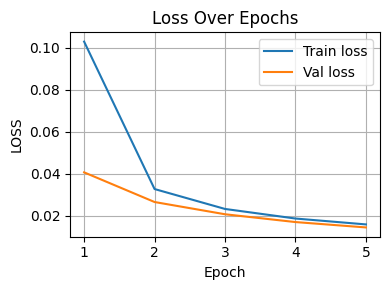

In [16]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

As can be seen in the mean squared error vs. epoch plot above, the FFN is able to learn patterns from the flattened sequential data. However, there are two major drawbacks to using this technique for sequence modeling.

* Firstly, the FFN assumes that the input has a fixed length. This means that if we have fewer or more than 144 samples as the input, we cannot trivially use the above FFN to make predictions.
* Secondly, the model size increases with every increase in sequence length. For instance, if we are training with 1 month of context as opposed to 1 day, the size grows from 27,907 parameters to 829,699 parameters. This is because every part of the input is fully connected to every part of the hidden representation, which is fully connected to every part of the output.

This indicates that we might be using a somewhat inefficient parameterization of our model, and we might benefit from designing the model architecture differently so that we can reuse some parameters when processing sequences regardless of how long or short they are. This is one benefit of RNNs. In the next three sections, we attempt a detailed implementation of three different types of RNNs: the simple RNN, the long short-term memory network, and the gated recurrent unit.

### 3.1 The Simple RNN

When we implemented the FFN earlier, we flattened the input, then multiplied it by a weight matrix and added a bias to compute the hidden representation, which we passed to the output layer. A similar operation is performed for RNNs, except we do not flatten the input. Instead, we create a weight matrix and bias vector that we can use to transform each individual sample into a hidden representation. So instead of what we did earlier for the FFN:

In [17]:
W_xh = torch.randn(432, 64)
W_bh = torch.randn(64)

x_flat = X.reshape(-1, 432)
hid_repr = F.tanh(x_flat @ W_xh + W_bh)
hid_repr.shape

torch.Size([128, 64])

We have:

In [18]:
W_xh = torch.randn(3, 64)
W_bh = torch.randn(64)

outputs = []

for t in range(X.shape[1]):
    # for every timestep
    x_t = X[:, t]  # get the sample at timestep t
    hid_repr = F.tanh(x_t @ W_xh + W_bh)
    outputs.append(hid_repr)

# stack the hidden representations batch_first
# i.e (batch_size, seq_length, hidden_size)
# with dim=1 to match the shape of the input
outputs = torch.stack(outputs, dim=1)
outputs.shape

torch.Size([128, 144, 64])

We now end up with a sequence of 144 hidden representations obtained by transforming the sample at every timestep. The representations, however, are independent of each other. This means that if we are trying to build a sequence model out of these representations, we still need to solve the previous problem of learning patterns in their ordering. The way RNNs solve this, which is what makes them recurrent, is by using recurrent connections. With recurrent connections, RNNs can use representations from previously processed timesteps to compute the representation at the current timestep. What makes one RNN architecture different from another is how they compute or combine information from previous hidden representations. For the simple RNN architecture we are currently implementing, at a particular timestep, we transform the hidden representation of the previous timestep using a weight matrix and add the result to the transformed input from the current timestep. At the first timestep, we cannot have a previous timestep, so we use a zero vector instead. This is beneficial because it disables the recurrent connection since multiplying the zero vector by the weight matrix results in a zero vector. Hidden representations obtained at every timestep using RNNs (after applying the recurrent connections) are called hidden states. We compute them below.

In [19]:
W_xh = torch.randn(3, 64)
W_hh = torch.randn(64, 64)
b_h = torch.randn(64)

outputs = []
hidden_state = torch.zeros(batch_size, 64)  # initial hidden state

for t in range(X.shape[1]):
    x_t = X[:, t]
    hidden_state = F.tanh(x_t @ W_xh + hidden_state @ W_hh + b_h)
    outputs.append(hidden_state)

outputs = torch.stack(outputs, dim=1)
outputs.shape

torch.Size([128, 144, 64])

And with that, the hidden state at a particular timestep depends on the hidden states at the timesteps before it, and it can influence the hidden states at timesteps that come after it. This means that temporal patterns in sequential data can be captured with RNNs given the right parameter values. This type of RNN can also be called standard RNN, vanilla RNN, or Elman network. It was introduced by [Jeffrey Elman in 1990](https://papers.baulab.info/papers/Elman-1990.pdf).

The $\tanh$ function is used when computing hidden states because it bounds their values between -1 and 1 as they are repeatedly updated through the recurrent computation over the entire sequence, preventing the hidden state values from exploding. In addition, the zero-centered nature of $\tanh$ allows for more balanced gradients compared to the sigmoid function, which can help speed up convergence (training).

Now that we have a sequence of hidden states, with the current hidden state depending on the past hidden state and the current input, we can pick the final hidden state to pass to the regressor output layer for weather forecasting because it contains information obtained from processing the entire input sequence. Below is the complete implementation of a simple RNN.

In [20]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, std=0.01):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, input, h=None):
        if h is None:
            h = torch.zeros((input.shape[0], self.hidden_size), device=input.device)

        outputs = []
        for t in range(input.shape[1]):
            x_t = input[:, t]
            h = F.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
            outputs.append(h)
        outputs = torch.stack(outputs, dim=1)

        return outputs, h


class RNNRegressor(Regressor):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = RNN(input_size, hidden_size)

    def get_hidden(self, inputs):
        outputs, h = self.rnn(inputs)
        return h

In [21]:
input_size = 3
rnn_regressor = RNNRegressor(input_size, hidden_size)  # hidden_size = 64
summary(rnn_regressor, X)[:-4]

,Layer,Output Shape,Params
0,RNNRegressor_0,"[128, 3]",4547
1,Linear_1,"[128, 3]",195
2,RNN_1,"[128, 144, 64]",4352
3,,,
4,Total Params:,,"4,547 (17.76 KB)"
5,Trainable Params:,,"4,547 (17.76 KB)"
6,Non-trainable Params:,,0 (0.00 B)


As seen above, our model goes from 27,907 parameters in the FFN to 4,547 parameters in the simple RNN. In addition to that, we can use the same RNN parameters to process an arbitrary-length sequence as opposed to a fixed-length sequence like in FFNs.

We now create a trainer object and train the RNN with the hyperparameters used previously, but this time, and for the other RNNs, we add norm-based gradient clipping with a threshold value of 1. RNNs are as deep as the length of the sequence that they process. We describe this by saying they are deep in the time or temporal dimension. Because of this, we use gradient clipping to address potential gradient explosion. While tanh controls the size of the hidden states in the forward pass, gradient clipping controls the size of the gradients used to update the RNN's parameters during the backward pass.

During training, obtaining the gradients for parameters in RNNs is done via Backpropagation Through Time (BPTT). This is similar to standard backpropagation, where we use the chain rule to compute derivatives of the model's error with respect to its parameters, except that we take into account the fact that we reuse the same parameters across multiple timesteps in RNNs. This means that the gradients computed at every timestep are summed for each parameter to obtain a single gradient per parameter. This gradient is then clipped using gradient clipping and used to update the shared parameters during gradient descent.

In [22]:
grad_clip_val = 1
optimizer = torch.optim.SGD(rnn_regressor.parameters(), lr=lr)

trainer = Trainer(
    rnn_regressor,
    optimizer,
    loss_fn,
    grad_clip_val=grad_clip_val,
)

Validating: 100%|██████████| 81/81 [00:02<00:00, 40.15it/s, val_loss=0.0033]


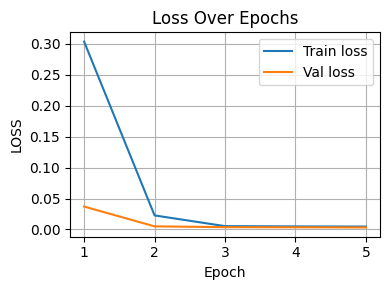

In [23]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

### 3.2 Long Short-Term Memory (LSTM)

In theory, given a large enough hidden state, simple RNNs can learn patterns across a very wide range of sequences, including language, speech, audio, video, and so on. In practice, however, training them with gradients obtained using BPTT can be difficult because of gradient instability. Exploding gradients, which we discussed earlier, can be addressed using gradient clipping to make training more stable. In addition to this, vanilla RNNs are highly prone to vanishing gradients during BPTT. This occurs when gradient signals shrink exponentially as we go back in time, making parameter updates at earlier timesteps very small or even impossible. This can prevent vanilla RNNs from learning long-range dependencies. Because simple RNNs repeatedly apply the recurrent transformation to update the hidden state at every timestep, computing gradients with respect to earlier timesteps involves repeatedly multiplying derivatives through this recurrent computation. When these derivatives have magnitudes smaller than one, the resulting gradients can become progressively smaller as we move backwards through time.

LSTMs differ from simple RNNs in that they use a more intricate way of computing and updating hidden states that makes them less prone to the vanishing gradient problem during BPTT, consequently enabling them to capture long-term relationships between samples in a sequence. Instead of only having a hidden state that is transformed at every timestep in combination with the input at that timestep to produce the next hidden state, an LSTM maintains a cell state as it processes a sequence. The cell state acts as a dynamically updated memory that the LSTM can choose to add information to or remove information from using "smart filters" called gates. Gates in LSTMs control how much information is added to or removed from the cell state and how much information from the cell state is used to produce the hidden state. The cell state also provides a more direct path for information and gradients to flow through the sequence, which helps reduce the vanishing gradient problem. We now proceed to do a step-by-step implementation of LSTMs.

Given an arbitrary state vector, a gate applied to it is a vector of the same size with entries that range from 0 to 1. The gate operates on the state through elementwise multiplication. State vector entries that are multiplied by gate values close to one are mostly preserved, while those multiplied by values close to zero are mostly suppressed. This is demonstrated below:

In [24]:
state = torch.tensor([1, 2, 3, 4])
gate = torch.tensor([1, 0.8, 0.5, 0])

output = state * gate
output

tensor([1.0000, 1.6000, 1.5000, 0.0000])

As described earlier, the gates in LSTMs are used to determine how much information to add to and retain in the cell state, and how much information from the cell state to use when computing the hidden state at every timestep. The gate that determines how much new information to add to the cell state is the *input gate*, the gate that determines how much of the previous cell state to retain is the *forget gate*, and the gate that determines how much of the cell state is used to compute the hidden state is the *output gate*. Just like the hidden states of simple RNNs, the values of these gates depend on the input at the current timestep, the hidden state at the previous timestep, and learnable parameters. This makes LSTMs robust and applicable to a wide range of sequence modeling tasks without relying on handcrafted gates. However, the activation function used for computing the gates is the sigmoid function because it restricts gate values to the range of 0 to 1, which is important for controlling how much information passes through each gate. With these in mind, LSTM gates can be constructed as follows:

In [25]:
# input gate parameters
W_xi = torch.randn(3, 64)
W_hi = torch.randn(64, 64)
b_i = torch.randn(64)

# forget gate parameters
W_xf = torch.randn(3, 64)
W_hf = torch.randn(64, 64)
b_f = torch.randn(64)

# output gate parameters
W_xo = torch.randn(3, 64)
W_ho = torch.randn(64, 64)
b_o = torch.randn(64)

hidden_state = torch.zeros(batch_size, 64)

for t in range(X.shape[1]):
    x_t = X[:, t]
    input_gate = F.sigmoid(x_t @ W_xi + hidden_state @ W_hi + b_i)
    forget_gate = F.sigmoid(x_t @ W_xf + hidden_state @ W_hf + b_f)
    output_gate = F.sigmoid(x_t @ W_xo + hidden_state @ W_ho + b_o)

Now we have to describe how an LSTM computes its cell state and hidden state representation at every timestep. Just like in simple RNNs, the hidden state and cell state are initialized to zero at the start of a sequence, and a *candidate cell state* is computed at every timestep via the familiar operation:

In [26]:
cell_state = torch.zeros(batch_size, 64)
hidden_state = torch.zeros(batch_size, 64)

W_xc = torch.randn(3, 64)
W_hc = torch.randn(64, 64)
b_c = torch.randn(64)


for t in range(X.shape[1]):
    x_t = X[:, t]
    cand_cell_state = F.tanh(x_t @ W_xc + hidden_state @ W_hc + b_c)

The candidate cell state represents the new information that we are proposing to add to the actual cell state. In addition to that, there is likely old information that we want to remove from the actual cell state at the current timestep that is coming from the previous timestep. LSTMs achieve addition and removal of information from their cell state with a gating system expressed in the equation below:

$$
cell\_state = forget\_gate \odot previous\_cell\_state + input\_gate \odot candidate\_cell\_state
$$

The $\odot$ operator represents the elementwise product. As we can see, the forget gate determines which information from the previous cell state to retain or forget, and the input gate determines which information from our proposed cell state to incorporate into the cell state. If the forget gate is a vector of ones, the LSTM retains all the previous information, while if it is a zero vector, it discards all the previous information. With values in between these two extremes, the forget gate can selectively choose what information to retain or forget. The same applies to the input gate, except a zero-vector input gate means no information is added at that timestep, while an all-ones vector implies adding all the candidate information to the cell state.

Finally, the hidden state at every timestep is calculated from the cell state using:

$$
hidden\_state = output\_gate \odot \tanh(cell\_state)
$$

This indicates that the output gate determines how much of the cell state is used to compute the hidden state at the current timestep. The $\tanh$ function here is used for the same reason as the $\tanh$ in simple RNNs, which is primarily to bound the hidden state values between -1 and 1. The hidden state serves as input to the output layer for prediction and as input for computing the three gates and candidate cell state at the next timestep.

We put everything together to build the LSTM architecture below:

In [27]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, std=0.01):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xi = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hi = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))

        self.W_xf = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hf = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))

        self.W_xo = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_ho = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        self.W_xc = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hc = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, inputs, hc=None):
        if hc is None:
            h = torch.zeros((inputs.shape[0], self.hidden_size), device=inputs.device)
            c = torch.zeros((inputs.shape[0], self.hidden_size), device=inputs.device)
        else:
            h, c = hc

        outputs = []
        for t in range(inputs.shape[1]):
            x_t = inputs[:, t]
            i = F.sigmoid(x_t @ self.W_xi + h @ self.W_hi + self.b_i)
            f = F.sigmoid(x_t @ self.W_xf + h @ self.W_hf + self.b_f)
            o = F.sigmoid(x_t @ self.W_xo + h @ self.W_ho + self.b_o)
            cand_c = F.tanh(x_t @ self.W_xc + h @ self.W_hc + self.b_c)

            c = f * c + i * cand_c
            h = o * torch.tanh(c)
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1)
        return outputs, (h, c)


class LSTMRegressor(Regressor):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = LSTM(input_size, hidden_size)

    def get_hidden(self, inputs):
        outputs, (h, c) = self.lstm(inputs)
        return h


lstm_regressor = LSTMRegressor(input_size, hidden_size)
summary(lstm_regressor, X)[:-4]

,Layer,Output Shape,Params
0,LSTMRegressor_0,"[128, 3]",17603
1,Linear_1,"[128, 3]",195
2,LSTM_1,"[128, 144, 64]",17408
3,,,
4,Total Params:,,"17,603 (68.76 KB)"
5,Trainable Params:,,"17,603 (68.76 KB)"
6,Non-trainable Params:,,0 (0.00 B)


The LSTM network was introduced in [1997 by Sepp Hochreiter and Jürgen Schmidhuber](https://deeplearning.cs.cmu.edu/S23/document/readings/LSTM.pdf). In the simple RNN architecture, the hidden state is updated at every timestep using information from the previous hidden state and the current input. For this reason, the simple RNN architecture is said to have a short-term memory through its hidden state. On the other hand, the LSTM architecture uses the cell state, also called the memory cell, to convey information across timesteps, along with gates to determine what information is added to and removed from the memory cell and how it affects the hidden state at every timestep. With this setup, information in the short-term memory can be preserved and carried along for much longer in the sequence, hence the name long short-term memory.

On the training side, we suggested that training vanilla RNNs with gradients obtained via BPTT makes them highly prone to the vanishing gradient problem. This is because of the repeated chain of matrix multiplications carried out across the sequence to update the hidden state. As we have seen, the LSTM uses a cell state, a gating system, and an addition operation to update its cell state. When the forget gate values are close to 1, gradient signals can propagate backwards through multiple timesteps with much less multiplicative shrinking than in a simple RNN. Generally speaking, the dynamic nature of the gates allows the LSTM to control how information is retained, added, and exposed at each timestep, which helps it preserve information over longer sequences and reduces the vanishing gradient problem.

We now proceed to training the LSTM model.

In [28]:
optimizer = torch.optim.SGD(lstm_regressor.parameters(), lr=lr)
trainer = Trainer(
    lstm_regressor,
    optimizer,
    loss_fn,
    grad_clip_val=grad_clip_val,
)

Validating: 100%|██████████| 81/81 [00:06<00:00, 13.06it/s, val_loss=0.0238]


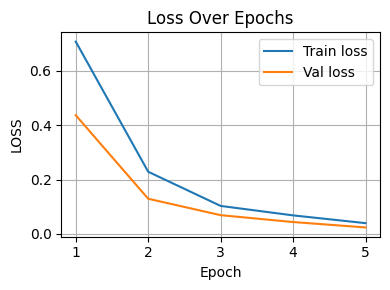

In [29]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

### 3.3 Gated Recurrent Unit (GRU)

The LSTM architecture is designed to address the vanishing gradient problem in simple RNNs trained with gradients obtained via BPTT, making it better for modeling long sequences. However, it requires more computation and roughly 4 times as many parameters as a simple RNN. To address this problem, the Gated Recurrent Unit (GRU) architecture was introduced [in 2014 by Kyunghyun Cho and a team of other researchers](https://arxiv.org/pdf/1406.1078). At its core, the GRU uses two gates instead of three, and it does not contain a cell state. On top of that, the GRU achieves comparable performance to the LSTM architecture for modeling long sequences. This makes GRUs more computationally efficient than LSTMs. We now move to the detailed implementation of the GRU.

As suggested earlier, the GRU contains two gates which are called the reset gate and the update gate. Their computation should be familiar.


In [30]:
# reset gate parameters
W_xr = torch.randn(3, 64)
W_hr = torch.randn(64, 64)
b_r = torch.randn(64)

# update gate parameters
W_xz = torch.randn(3, 64)
W_hz = torch.randn(64, 64)
b_z = torch.randn(64)

hidden_state = torch.zeros(batch_size, 64)

for t in range(X.shape[1]):
    x_t = X[:, t]
    reset_gate = F.sigmoid(x_t @ W_xr + hidden_state @ W_hr + b_r)
    update_gate = F.sigmoid(x_t @ W_xz + hidden_state @ W_hz + b_z)

Next, at every timestep, a *candidate hidden state* is computed as follows:

In [31]:
W_xh = torch.randn(3, 64)
W_hh = torch.randn(64, 64)
b_h = torch.randn(64)

for t in range(X.shape[1]):
    x_t = X[:, t]
    reset_gate = F.sigmoid(x_t @ W_xr + hidden_state @ W_hr + b_r)
    update_gate = F.sigmoid(x_t @ W_xz + hidden_state @ W_hz + b_z)
    cand_hidden_state = F.tanh(x_t @ W_xh + (reset_gate * hidden_state) @ W_hh + b_h)


The computation for the candidate hidden state resembles that of the hidden state in the vanilla RNN, with the addition of an elementwise multiplication between the reset gate and the previous hidden state. This indicates that the reset gate is responsible for determining how much information from the previous hidden state is used in the current proposed hidden state. Since the reset gate can contain values close to zero, it can discard information from the previous hidden state, leaving the candidate hidden state to depend primarily on the current timestep's input. Hence the name reset gate. The candidate hidden state is a proposed hidden state and not the actual hidden state. To obtain the actual hidden state, the candidate hidden state is combined with the update gate and previous hidden state as follows:

In [32]:
for t in range(X.shape[1]):
    x_t = X[:, t]
    reset_gate = F.sigmoid(x_t @ W_xr + hidden_state @ W_hr + b_r)
    update_gate = F.sigmoid(x_t @ W_xz + hidden_state @ W_hz + b_z)
    cand_hidden_state = F.tanh(x_t @ W_xh + (reset_gate * hidden_state) @ W_hh + b_h)
    hidden_state = update_gate * hidden_state + (1 - update_gate) * cand_hidden_state

The update gate is multiplied by the previous hidden state to determine how much information from the previous hidden state is retained in the current hidden state, while $1 - update\_gate$ is multiplied by the candidate hidden state to control how much information from the proposed hidden state is incorporated at the current timestep. If the update gate is a zero vector, the hidden state at the current timestep is the candidate hidden state and the previous hidden state is discarded. If the update gate is a vector of ones, the previous hidden state is used as the current hidden state while the candidate hidden state is ignored. In general, the update gate is used to take a weighted combination of the previous and candidate hidden states to determine how information from both is mixed to obtain the current hidden state.

We now implement the GRU model and train it below:

In [33]:
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, std=0.01):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xr = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hr = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_r = nn.Parameter(torch.zeros(hidden_size))

        self.W_xz = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hz = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_z = nn.Parameter(torch.zeros(hidden_size))

        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * std)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * std)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, input, h=None):
        if h is None:
            h = torch.zeros((input.shape[0], self.hidden_size), device=input.device)

        outputs = []

        for t in range(input.shape[1]):
            x_t = input[:, t]
            reset_gate = F.sigmoid(x_t @ self.W_xr + h @ self.W_hr + self.b_r)
            update_gate = F.sigmoid(x_t @ self.W_xz + h @ self.W_hz + self.b_z)
            cand_h = F.tanh(x_t @ self.W_xh + (reset_gate * h) @ self.W_hh + self.b_h)
            h = update_gate * h + (1 - update_gate) * cand_h
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1)
        return outputs, h


class GRURegressor(Regressor):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = GRU(input_size, hidden_size)

    def get_hidden(self, input):
        outputs, h = self.gru(input)
        return h


gru_regressor = GRURegressor(input_size, hidden_size)
summary(gru_regressor, X)[:-4]

,Layer,Output Shape,Params
0,GRURegressor_0,"[128, 3]",13251
1,Linear_1,"[128, 3]",195
2,GRU_1,"[128, 144, 64]",13056
3,,,
4,Total Params:,,"13,251 (51.76 KB)"
5,Trainable Params:,,"13,251 (51.76 KB)"
6,Non-trainable Params:,,0 (0.00 B)


In [34]:
optimizer = torch.optim.SGD(gru_regressor.parameters(), lr=lr)
trainer = Trainer(
    gru_regressor,
    optimizer,
    loss_fn,
    grad_clip_val=grad_clip_val,
)

Validating: 100%|██████████| 81/81 [00:05<00:00, 13.86it/s, val_loss=0.0035]


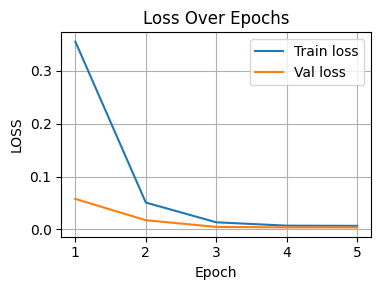

In [35]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

### 3.4 Stacked RNNs

When implementing feedforward networks, we can make the network deeper by stacking more layers between the input and the output. By doing so, the first layer takes the input and produces a hidden representation, then the second layer takes the hidden representation and produces another hidden representation, and so on until the final layer, which takes the final hidden representation and produces the output. This increases the ability of the neural network to learn complex patterns because additional layers can learn representations that make the output prediction easier.

Since RNNs produce hidden states at every timestep, it turns out that we can stack multiple RNNs on top of each other so that the input at every timestep passes through multiple layers at the same timestep in order to compute the final hidden state at that timestep. To achieve this, we process the input sequence with the first RNN in the stack, producing a sequence of hidden states. We then use the second RNN in the stack to process the hidden states obtained from the first RNN to produce another sequence of hidden states. We repeat this for every RNN in the stack and then feed the last hidden state from the final RNN into the output layer for predictions. We illustrate this concept with three RNNs below:

In [36]:
rnn1 = RNN(3, 64)
rnn2 = RNN(64, 64)
rnn3 = RNN(64, 64)

output1, h1 = rnn1(X)
output2, h2 = rnn2(output1)
output3, h3 = rnn3(output2)

output3.shape, h3.shape

# We can now pass h3 to the output layer

(torch.Size([128, 144, 64]), torch.Size([128, 64]))

This is the same method used to stack LSTMs and GRUs. We now implement the stacked RNN architecture and train it on the dataset.

In [37]:
class StackedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_hiddens = hidden_size
        self.num_layers = num_layers
        rnn_layers = [RNN(input_size, hidden_size)]  # rnn1

        for _ in range(num_layers - 1):
            rnn_layers.append(RNN(hidden_size, hidden_size))

        self.rnns = nn.ModuleList(rnn_layers)

    def forward(self, inputs, hs=None):
        outputs = inputs

        if hs is None:
            hs = [None] * self.num_layers

        for i in range(self.num_layers):
            # hs contains the final hidden state of every
            # RNN in the stack.
            outputs, hs[i] = self.rnns[i](outputs, hs[i])

        return outputs, hs


class StackedRNNRegressor(Regressor):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.stacked_rnn = StackedRNN(input_size, hidden_size, num_layers)

    def get_hidden(self, input):
        outputs, hs = self.stacked_rnn(input)
        return hs[-1]


stacked_rnn_regressor = StackedRNNRegressor(input_size, hidden_size, 2)
summary(stacked_rnn_regressor, X)[:-4]

,Layer,Output Shape,Params
0,StackedRNNRegressor_0,"[128, 3]",12803
1,Linear_1,"[128, 3]",195
2,StackedRNN_1,"[128, 144, 64]",12608
3,ModuleList_2,None,12608
4,,,
5,Total Params:,,"12,803 (50.01 KB)"
6,Trainable Params:,,"12,803 (50.01 KB)"
7,Non-trainable Params:,,0 (0.00 B)


In [38]:
optimizer = torch.optim.SGD(stacked_rnn_regressor.parameters(), lr=lr)
trainer = Trainer(
    stacked_rnn_regressor,
    optimizer,
    loss_fn,
    grad_clip_val=grad_clip_val,
)

Validating: 100%|██████████| 81/81 [00:03<00:00, 23.43it/s, val_loss=0.0271]


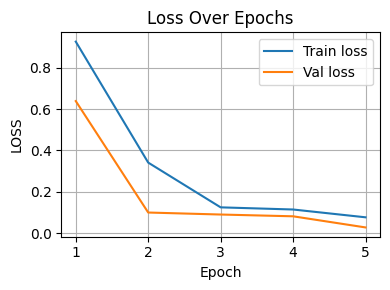

In [39]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

### 3.5 Many-to-Many Sequence Modeling

We have been focusing on the task of predicting the weather measurements (temperature, pressure, and relative humidity) given a sequence of 144 measurements made 10 minutes apart. For that reason, we designed the data loader accordingly to generate a sequence of 144 measurements as the input and the next measurement observation as the output. Also, in training the RNN models, we pass the hidden state at the final timestep to the output layer for prediction. This is called many-to-one sequence modeling because we have 144 observations as the input and 1 observation as the output.

When RNNs process a sequence of inputs, they produce a sequence of hidden states at every timestep. Since we have the ground truth values at every timestep, we can pass every hidden state to the output layer, compute the mean squared error between the model's predictions and the ground truth at every timestep, apply BPTT to obtain gradients, and update the model parameters using gradient descent. This gives us a loss signal at every timestep rather than only at the final timestep, providing more learning signal per forward pass and potentially speeding up training.

To achieve this, we have to start by changing how the data is loaded. Instead of:

$$
input: x_1, x_2, ..., x_{144} \\
output: x_{145}
$$

We have:

$$
input: x_1, x_2, ..., x_{144} \\
output: x_2, x_3, ..., x_{145}
$$

This means that the output has the same length as the input and is produced by shifting the input by one observation to the right. Below is the data loader that achieves this:

In [40]:
class WeatherDataset(Dataset):
    def __init__(self, data, seq_length=144):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + 1 : idx + self.seq_length + 1]
        return x, y

In [41]:
train_dataset = WeatherDataset(train_data, seq_length)
val_dataset = WeatherDataset(val_data, seq_length)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

X, y = next(iter(train_loader))
X.shape, y.shape

(torch.Size([128, 144, 3]), torch.Size([128, 144, 3]))

We use a GRU regressor to demonstrate many-to-many sequence modeling.

In [42]:
class M2MGRURegressor(Regressor):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = GRU(input_size, hidden_size)

    def get_hidden(self, input):
        outputs, h = self.gru(input)
        return outputs


m2m_gru_regressor = M2MGRURegressor(input_size, hidden_size)
summary(m2m_gru_regressor, X)[:-4]

,Layer,Output Shape,Params
0,M2MGRURegressor_0,"[128, 144, 3]",13251
1,Linear_1,"[128, 144, 3]",195
2,GRU_1,"[128, 144, 64]",13056
3,,,
4,Total Params:,,"13,251 (51.76 KB)"
5,Trainable Params:,,"13,251 (51.76 KB)"
6,Non-trainable Params:,,0 (0.00 B)


As can be seen above, the only change we made (apart from naming, of course) is that we pass the sequence of hidden states at every timestep (outputs) instead of the final hidden state (h) to the output layer. The output layer will then make a prediction for every timestep, which we can compare with the ground truth at the respective timesteps. We can now train the GRU regressor as usual.

In [43]:
optimizer = torch.optim.SGD(m2m_gru_regressor.parameters(), lr=lr)
trainer = Trainer(
    m2m_gru_regressor,
    optimizer,
    loss_fn,
    grad_clip_val=grad_clip_val,
)

Validating: 100%|██████████| 81/81 [00:05<00:00, 15.13it/s, val_loss=0.0065]


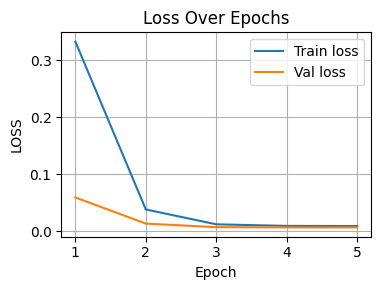

In [44]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)
trainer.plot(figsize=figsize)

This is the technique commonly used to train RNNs and many other sequence models when predicting the next sample in a sequence of samples. We use this same technique for language modeling (coming soon). There is also a many-to-many case where the lengths of the input and output sequences are not equal. This happens in machine translation, for instance, where the length of a sentence in the source language can be longer or shorter than its translation in the target language. We can solve this using an encoder RNN that processes the input and a decoder RNN that generates the output from the hidden state of the encoder, e.g. by initializing the hidden state (and cell state for LSTMs) with the final hidden state of the encoder instead of zeros. We will provide an implementation of this soon.

## 4 Summary

An RNN cell is the fundamental unit that contains the computation or operations performed at a single timestep.

In a vanilla RNN cell:
$$H_t = \tanh(X_tW_{xh} + H_{t-1}W_{hh} + b_h)$$

In an LSTM cell:
$$I_t = \operatorname{sigmoid}(X_tW_{xi} + H_{t-1}W_{hi} + b_i)$$
$$F_t = \operatorname{sigmoid}(X_tW_{xf} + H_{t-1}W_{hf} + b_f)$$
$$O_t = \operatorname{sigmoid}(X_tW_{xo} + H_{t-1}W_{ho} + b_o)$$
$$\tilde{C}_t = \tanh(X_tW_{xc} + H_{t-1}W_{hc} + b_c)$$
$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t$$
$$H_t = O_t \odot \tanh(C_t)$$

In a GRU cell:
$$Z_t = \operatorname{sigmoid}(X_tW_{xz} + H_{t-1}W_{hz} + b_z)$$
$$R_t = \operatorname{sigmoid}(X_tW_{xr} + H_{t-1}W_{hr} + b_r)$$
$$\tilde{H}_t = \tanh(X_tW_{xh} + (R_t \odot H_{t-1})W_{hh} + b_h)$$
$$H_t = Z_t \odot H_{t-1} + (1 - Z_t) \odot \tilde{H}_t$$

where $H_t, I_t, F_t, O_t, \tilde{C}_t, C_t, R_t, Z_t,$ and $\tilde{H}_t$ are the hidden state, input gate, forget gate, output gate, candidate cell state, cell state, reset gate, update gate, and candidate hidden state at timestep $t$, respectively. They are all of shape `(batch size, hidden size)`.

The weight matrices $W_{xh}, W_{xi}, W_{xf}, W_{xo}, W_{xc}, W_{xr}, W_{xz}$ transform the input and have shape `(input size, hidden size)`. The weight matrices $W_{hh}, W_{hi}, W_{hf}, W_{ho}, W_{hc}, W_{hr}, W_{hz}$ transform the hidden state at timestep $t-1$ and have shape `(hidden size, hidden size)`. The bias vectors $b_h, b_i, b_f, b_o, b_c, b_r,$ and $b_z$ have shape `(hidden size,)`.

The input at timestep $t$, $X_t$, has shape `(batch size, input size)`, while the full input sequence $X$ has shape `(batch size, sequence length, input size)`.

## 5 Conclusion

In this notebook, we studied the concept of sequence modeling, built data loaders for sequential data, implemented different RNN architectures, and trained them to model sequential data. While there are many other types of RNN architectures, simple RNNs, LSTMs, and GRUs are foundational RNN architectures for sequence modeling. Understanding them can also inspire one to experiment with creating new RNN architectures or sequence-modeling ANNs in general.

## 6 References

- [Elman, J. L. (1990). Finding structure in time.](https://papers.baulab.info/papers/Elman-1990.pdf)
- [Hochreiter, S. & Schmidhuber, J. (1997) Long short-term memory.](https://deeplearning.cs.cmu.edu/S23/document/readings/LSTM.pdf)
- [Cho, K. et al. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation.](https://arxiv.org/pdf/1406.1078)
- [Chung, J. et al. (2014). Empirical evaluation of gated recurrent neural networks on sequence modeling.](https://arxiv.org/pdf/1412.3555)
- [Józefowicz, R. et al. (2015). An empirical exploration of recurrent network architectures.](https://proceedings.mlr.press/v37/jozefowicz15.pdf)
- [Zhang, A. et al. (2023). Dive into deep learning, Chapter 9 & 10.](https://d2l.ai)
